# Develop an analysis workflow

### **Goal:** 

build an analysis workflow centered on database interactions

### **Requirements:**

* completion of all previous tutorials

### **Contents:**

* create a summary visualization of the dataset

In [1]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from epiphyte.database.db_setup import *


/home/slappermk2/miniconda3/envs/epiphyte/lib/python3.9/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-03-06 13:30:57,090][INFO]: DataJoint 0.14.9 connected to root@127.0.0.1:3306


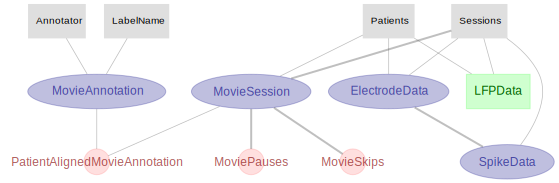

In [ ]:
erd = dj.ERD(epi_schema)
erd

### Create a summary visualization of all units in the database

In [26]:
su_count = len(ElectrodeData & "unit_type='S'")
mu_count = len(ElectrodeData & "unit_type='M'")

region_df = pd.DataFrame(
{    "patient_id": ElectrodeData.fetch("patient_id"),
    "session_nr": ElectrodeData.fetch("session_nr"),
    "region": ElectrodeData.fetch("brain_region")}
)


counts = (
    region_df
    .groupby(["patient_id", "session_nr", "region"])
    .size()
    .reset_index(name="count")
)

counts["patient_session"] = (
    counts["patient_id"].astype(str) + "_s" + counts["session_nr"].astype(str)
)

pivot_df = counts.pivot(
    index="patient_session",
    columns="region",
    values="count"
).fillna(0)

annotations_df = pd.DataFrame(MovieAnnotation())



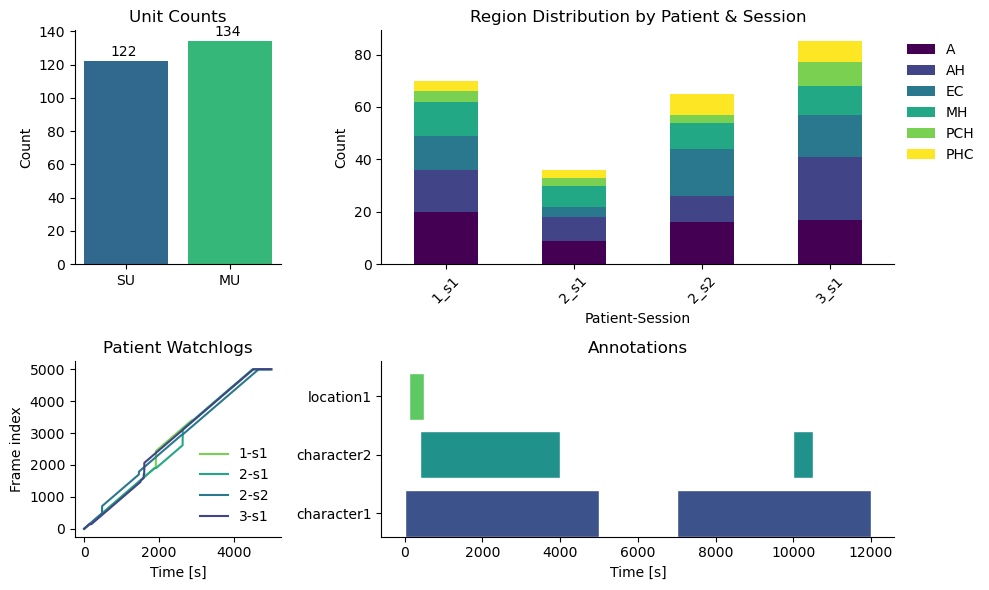

In [71]:
mosaic = """
    ABB
    CDD
    """

fig = plt.figure(figsize=(6,3),)
axes = fig.subplot_mosaic(
    mosaic,
    gridspec_kw={
        "height_ratios": [2, 1.5]  
    }
)

######
ax = axes["A"]
bar_colors = sns.color_palette("viridis",  n_colors=2)
ax.bar([0, 1], [su_count, mu_count], color=bar_colors)
ax.text(0-0.15, su_count+3, f"{su_count}")
ax.text(1-0.15, mu_count+3, f"{mu_count}")
ax.set_xticks([0,1])
ax.set_xticklabels(["SU", "MU"])
ax.set_ylabel("Count")
ax.set_title("Unit Counts")
sns.despine(ax=ax)

######
ax = axes["B"]
pivot_df.plot(
    ax=ax,
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="viridis"
)
ax.legend(frameon=False, bbox_transform=ax.transAxes, bbox_to_anchor = [1,1])
ax.set_title("Region Distribution by Patient & Session")
ax.set_xlabel("Patient-Session")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)
sns.despine(ax=ax)

######
ax = axes["D"]
yticks = []
ylabels = []
y_pos = 0

bar_colors = sns.color_palette("viridis",  n_colors=3)
bar_height = 0.8  

for idx, row in annotations_df.iterrows():
    starts = row['start_times']  
    stops = row['stop_times']
    values = row['values']
    color = bar_colors[idx]
    label = row['label_name']

    for start, stop, value in zip(starts, stops, values):
        if value:
            ax.axvspan(
                xmin=start,
                xmax=stop,
                ymin=y_pos / len(annotations_df),
                ymax=(y_pos + bar_height) / len(annotations_df),
                facecolor=color,
                alpha=1.0,
                edgecolor='white'
            )
    
    yticks.append(y_pos + bar_height / 2)
    ylabels.append(label)
    y_pos += 1 
ax.set_ylim(0, len(annotations_df))
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_xlabel("Time [s]")
ax.set_title("Annotations")
sns.despine(ax=ax)

######
ax = axes["C"]
pats, seshs = MovieSession.fetch("patient_id", "session_nr")
colors = sns.color_palette("viridis_r", n_colors=len(pats)) 
i = 0
for pat, sesh in zip(pats, seshs):
    
    pts, dts = (MovieSession & f"patient_id={pat}" & f"session_nr={sesh}").fetch("pts", "dts")
    pts = pts[0]
    dts = dts[0] - dts[0][0]
    dts = dts / 1000 / 1000

    ax.plot(dts, pts, color=colors[i], label=f"{pat}-s{sesh}")
    i += 1

ax.set_title("Patient Watchlogs")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frame index")

sns.despine(ax=ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()